<a href="https://colab.research.google.com/github/nileve-teo/Metodos-numericos/blob/main/Integraci%C3%B3n_num%C3%A9rica2_9_de_Junio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="
width:21cm;
max-width:21cm;
box-sizing:border-box;
margin:auto;
background-color:#E3D5B4;
border-top:2px solid #444;
padding-top:18px;
padding-bottom:18px;
padding-left:20px;
padding-right:20px;
font-family:Georgia;
overflow:hidden;
">

<div style="
text-align:left;
font-size:42px;
color:#1f1f1f;
margin-bottom:12px;
">
INTEGRACIÓN NUMÉRICA
</div>

<div style="
width:100%;
box-sizing:border-box;
background-color:#2E6599;
color:white;
font-size:38px;
padding:20px 30px;
text-align:right;
">
Gauss-Legendre: Nodos Óptimos
</div>

</div>

<div style="
width:21cm;
max-width:21cm;
box-sizing:border-box;
margin:auto;
background-color:#F2F0E6;
border-top:2px solid #444;
padding:20px;
font-family:Georgia;
overflow:hidden;
line-height:1.7;
">

<h2 style="
color:#2E6599;
font-family:'Avenir Arabic Roman','Avenir','Helvetica Neue',Arial,sans-serif;
font-weight:700;
">
Ejercicio 1 – Clase de Laboratorio
</h2>

Desarrolle un **script en Python** para resolver las siguientes integrales.

<div style="
background-color:#ECE9DC;
padding:15px;
border-radius:8px;
text-align:center;
margin-top:15px;
margin-bottom:15px;
">

$$
f(x)=\frac{1}{\sqrt{2\pi}}e^{-x^2/2}
$$

$$
f(x)=\cos(x^2)
$$

$$
f(x)=x^5-2x^3+4
$$

</div>

Optimice su código para que la función pueda ingresarse desde pantalla y no sea necesario modificar el programa constantemente.

Además, el código debe:

- Identificar automáticamente si la función es **polinómica**.
- Determinar automáticamente el número óptimo de nodos para **Gauss-Legendre**.
- Obtener la solución exacta cuando sea posible.

**Nota:** Al utilizar Cuadratura de Gauss-Legendre de \(n\) puntos, las raíces y los pesos deben calcularse de forma **algorítmica**.

<h2 style="
color:#2E6599;
font-family:'Avenir Arabic Roman','Avenir','Helvetica Neue',Arial,sans-serif;
font-weight:bold;
">
Métodos Numéricos Requeridos
</h2>

- **Regla del Trapecio Compuesta** (N = 12 subintervalos)
- **Regla de Simpson 1/3 Compuesta** (N = 12 subintervalos)
- **Regla de Simpson 3/8 Compuesta** (N = 12 subintervalos)
- **Cuadratura de Gauss-Legendre**
  - Utilizar únicamente **n = 5** para las dos primeras integrales.
  - Escoger automáticamente el valor óptimo de **n** para la tercera integral.

<h2 style="
color:#2E6599;
font-family:'Avenir Arabic Roman','Avenir','Helvetica Neue',Arial,sans-serif;
font-weight:700;
">
Presentación de Resultados
</h2>

| Método | Puntos F(x) | Aproximación | Error Absoluto |
|----------|----------|----------|----------|
| Trapecio Compuesto | | | |
| Simpson 1/3 Compuesto | | | |
| Simpson 3/8 Compuesto | | | |
| Gauss-Legendre | | | |


</div>

In [ ]:
# ============================================================
# LABORATORIO 1 - INTEGRACIÓN NUMÉRICA
# ============================================================

import numpy as np
import pandas as pd
import sympy as sp
from IPython.display import display, Math

x = sp.Symbol('x')

# ============================================================
# TRAPECIO COMPUESTO
# ============================================================

def trapecio_compuesto(f, a, b, N=12):

    X = np.linspace(a, b, N + 1)
    Y = f(X)

    h = (b - a) / N

    I = h * (
        0.5 * Y[0]
        + np.sum(Y[1:-1])
        + 0.5 * Y[-1]
    )

    return float(I), len(X)

# ============================================================
# SIMPSON 1/3 COMPUESTO
# ============================================================

def simpson13_compuesto(f, a, b, N=12):

    X = np.linspace(a, b, N + 1)
    Y = f(X)

    h = (b - a) / N

    I = (h/3) * (
        Y[0]
        + Y[-1]
        + 4*np.sum(Y[1:-1:2])
        + 2*np.sum(Y[2:-2:2])
    )

    return float(I), len(X)

# ============================================================
# SIMPSON 3/8 COMPUESTO
# ============================================================

def simpson38_compuesto(f, a, b, N=12):

    X = np.linspace(a, b, N + 1)
    Y = f(X)

    h = (b - a) / N

    suma = 0

    for i in range(1, N):

        if i % 3 == 0:
            suma += 2 * Y[i]
        else:
            suma += 3 * Y[i]

    I = (3*h/8) * (Y[0] + Y[-1] + suma)

    return float(I), len(X)

# ============================================================
# GAUSS LEGENDRE ALGORÍTMICO
# ============================================================

def gauss_legendre_algoritmico(expr, a, b, n):

    t = sp.Symbol('t')

    Pn = sp.legendre(n, t)

    raices = [float(r) for r in sp.nroots(Pn)]

    dPn = sp.diff(Pn, t)

    pesos = []

    for r in raices:

        dp = float(dPn.subs(t, r))

        w = 2 / ((1-r**2)*(dp**2))

        pesos.append(w)

    f = sp.lambdify(x, expr, "numpy")

    suma = 0

    for xi, wi in zip(raices, pesos):

        xp = ((b-a)/2)*xi + (a+b)/2

        suma += wi * f(xp)

    I = ((b-a)/2)*suma

    return float(I), n

# ============================================================
# DETECTAR POLINOMIO
# ============================================================

def detectar_grado(expr):

    try:

        grado = sp.Poly(expr, x).degree()

        return True, grado

    except:

        return False, None

# ============================================================
# INTEGRAL EXACTA
# ============================================================

def integral_exacta(expr, a, b):

    return sp.integrate(expr, (x, a, b))

# ============================================================
# CASOS DEL LABORATORIO
# ============================================================

casos = [

    {
        "nombre":"Integral 1",
        "expr":1/sp.sqrt(2*sp.pi)*sp.exp(-x**2/2),
        "a":0,
        "b":3,
        "n_gauss":5
    },

    {
        "nombre":"Integral 2",
        "expr":sp.cos(x**2),
        "a":0,
        "b":2,
        "n_gauss":5
    },

    {
        "nombre":"Integral 3",
        "expr":x**5 - 2*x**3 + 4,
        "a":-2,
        "b":3,
        "n_gauss":"auto"
    }

]

# ============================================================
# RESOLUCIÓN
# ============================================================

for caso in casos:

    expr = caso["expr"]
    a = caso["a"]
    b = caso["b"]

    exacta_simbolica = integral_exacta(expr, a, b)
    exacta = float(exacta_simbolica.evalf())

    f = sp.lambdify(x, expr, "numpy")

    es_pol, grado = detectar_grado(expr)

    if caso["n_gauss"] == "auto":

        n = int(np.ceil((grado + 1)/2))

    else:

        n = caso["n_gauss"]

    It, p1 = trapecio_compuesto(f, a, b)

    Is13, p2 = simpson13_compuesto(f, a, b)

    Is38, p3 = simpson38_compuesto(f, a, b)

    Ig, p4 = gauss_legendre_algoritmico(
        expr, a, b, n
    )

    # ========================================================
    # DESARROLLO ANALÍTICO
    # ========================================================

    print("\n")
    print("="*80)
    print(caso["nombre"])
    print("="*80)

    F = sp.integrate(expr, x)

    print("\nFUNCIÓN:")

    display(
        Math(
            r"f(x)=" + sp.latex(expr)
        )
    )

    print("\nINTEGRAL DEFINIDA:")

    display(
        Math(
            r"\int_{%s}^{%s}%s\,dx"
            %
            (
                sp.latex(a),
                sp.latex(b),
                sp.latex(expr)
            )
        )
    )

    # ========================================================
    # POLINOMIOS
    # ========================================================

    if es_pol:

        print("\nINTEGRACIÓN:")

        display(
            Math(
                r"\int %s\,dx=%s"
                %
                (
                    sp.latex(expr),
                    sp.latex(F)
                )
            )
        )

        print("\nEVALUANDO LOS LÍMITES:")

        display(
            Math(
                r"\left[%s\right]_{%s}^{%s}"
                %
                (
                    sp.latex(F),
                    sp.latex(a),
                    sp.latex(b)
                )
            )
        )

        Fa = sp.simplify(F.subs(x, a))
        Fb = sp.simplify(F.subs(x, b))

        display(
            Math(
                r"=\left(%s\right)-\left(%s\right)"
                %
                (
                    sp.latex(Fb),
                    sp.latex(Fa)
                )
            )
        )

        display(
            Math(
                r"=%s"
                %
                sp.latex(exacta_simbolica)
            )
        )

    # ========================================================
    # DISTRIBUCIÓN NORMAL
    # ========================================================

    elif expr.has(sp.exp):

        print("\nSOLUCIÓN ANALÍTICA:")

        print(
            "La integral se expresa mediante "
            "la función error erf(x)."
        )

        display(
            Math(
                r"F(x)=\frac12"
                r"\operatorname{erf}"
                r"\left(\frac{x}{\sqrt2}\right)"
            )
        )

        display(
            Math(
                r"\left[\frac12"
                r"\operatorname{erf}"
                r"\left(\frac{x}{\sqrt2}\right)"
                r"\right]_{0}^{3}"
            )
        )

        display(
            Math(
                r"=\frac12"
                r"\operatorname{erf}"
                r"\left(\frac3{\sqrt2}\right)"
            )
        )

    # ========================================================
    # FRESNEL
    # ========================================================

    else:

        print("\nSOLUCIÓN ANALÍTICA:")

        print(
            "La integral no posee una "
            "antiderivada elemental."
        )

        print(
            "Se expresa mediante funciones "
            "especiales de Fresnel."
        )

        display(
            Math(
                r"\int_0^2 \cos(x^2)\,dx"
            )
        )

    print(f"\nVALOR EXACTO = {exacta:.12f}")

    if es_pol:

        print(f"\nPolinomio de grado = {grado}")
        print(f"n óptimo Gauss-Legendre = {n}")

    # ========================================================
    # TABLA FINAL
    # ========================================================

    tabla = pd.DataFrame({

        "Método":[
            "Valor Exacto",
            "Trapecio Compuesto",
            "Simpson 1/3 Compuesto",
            "Simpson 3/8 Compuesto",
            "Gauss-Legendre"
        ],

        "Puntos F(x)":[
            "-",
            p1,
            p2,
            p3,
            p4
        ],

        "Aproximación":[
            exacta,
            It,
            Is13,
            Is38,
            Ig
        ],

        "Error Absoluto":[
            0,
            abs(exacta-It),
            abs(exacta-Is13),
            abs(exacta-Is38),
            abs(exacta-Ig)
        ]

    })

    display(
        tabla.style
        .hide(axis="index")
        .format({
            "Aproximación":"{:.10f}",
            "Error Absoluto":"{:.3e}"
        })
    )



Integral 1

FUNCIÓN:


<IPython.core.display.Math object>


INTEGRAL DEFINIDA:


<IPython.core.display.Math object>


SOLUCIÓN ANALÍTICA:
La integral se expresa mediante la función error erf(x).


...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>


VALOR EXACTO = 98.333333333333

Polinomio de grado = 5
n óptimo Gauss-Legendre = 3


Método,Puntos F(x),Aproximación,Error Absoluto
Valor Exacto,-,98.3333333333,0.000e+00
Trapecio Compuesto,13,102.5887144740,4.255e+00
Simpson 1/3 Compuesto,13,98.3835680298,5.023e-02
Simpson 3/8 Compuesto,13,98.4463614005,1.130e-01
Gauss-Legendre,3,98.3333333333,1.421e-14


<div style="
width:21cm;
max-width:21cm;
box-sizing:border-box;
margin:auto;
background-color:#F2F0E6;
border-top:2px solid #444;
padding:20px;
font-family:Georgia;
overflow:hidden;
line-height:1.7;
text-align:justify;
text-justify:inter-word;
">

<h2 style="
color:#2E6599;
font-family:'Avenir Arabic Roman','Avenir','Helvetica Neue',Arial,sans-serif;
font-weight:700;
">
 Análisis de Resultados
 </h2>

## 1. La Paradoja de los Puntos

Los métodos de Trapecio Compuesto, Simpson 1/3 Compuesto y Simpson 3/8 Compuesto utilizaron 12 subintervalos, lo que equivale a **13 evaluaciones de la función** en cada integral.

Por otro lado, la Cuadratura de Gauss-Legendre empleó únicamente:

- 5 nodos para las Integrales 1 y 2.
- 3 nodos para la Integral 3.

A pesar de utilizar una cantidad significativamente menor de evaluaciones,
Gauss-Legendre obtuvo resultados iguales o más precisos que los métodos de Newton-Cotes.

Esto demuestra que la precisión de un método de integración no depende únicamente de la cantidad de puntos utilizados, sino también de la ubicación óptima de dichos puntos dentro del intervalo.

## 2. Análisis del Error
<h2 style="
color:#2E6599">
Integral 1: Distribución Normal
 </h2>
</div>

<div style="
position:relative;
width:21cm;
max-width:21cm;
box-sizing:border-box;
margin:auto;
overflow:hidden;
padding:20px;
background:white;
border:2px solid #2E6599;
border-radius:12px;
">

<div style="
position:absolute;
bottom:-2px;
right:-2px;
width:0;
height:0;
border-bottom:40px solid #2E6599;
border-left:40px solid transparent;
">
</div>

<h4 style="
color:#2E6599;
margin-top:0;
font-family:'Avenir Arabic Roman';
">
Resultados de Integración
</h4>

| Método | Puntos F(x) | Aproximación | Error Absoluto |
|---------|---------|---------|---------|
| Trapecio Compuesto | 13 | 0.4985812865 | 6.882×10⁻⁵ |
| Simpson 1/3 Compuesto | 13 | 0.4986483856 | 1.716×10⁻⁶ |
| Simpson 3/8 Compuesto | 13 | 0.4986462838 | 3.818×10⁻⁶ |
| Gauss-Legendre | 5 | 0.4986490706 | 1.031×10⁻⁶ |

</div>

<div style="
width:21cm;
max-width:21cm;
box-sizing:border-box;
margin:auto;
background-color:#F2F0E6;
border-top:2px solid #444;
padding:20px;
font-family:Georgia;
overflow:hidden;
line-height:1.7;
text-align:justify;
text-justify:inter-word;
">

En esta función suave y continua, todos los métodos producen resultados aceptables; sin embargo, Gauss-Legendre logra el menor error utilizando solamente 5 puntos de evaluación.

<h2 style="
color:#2E6599">
Integral 2: Función de Fresnel
 </h2>

</div>

<div style="
position:relative;
width:21cm;
max-width:21cm;
box-sizing:border-box;
margin:auto;
overflow:hidden;
padding:20px;
background:white;
border:2px solid #2E6599;
border-radius:12px;
">

<div style="
position:absolute;
bottom:-2px;
right:-2px;
width:0;
height:0;
border-bottom:40px solid #2E6599;
border-left:40px solid transparent;
">
</div>

<h4 style="
color:#2E6599;
margin-top:0;
font-family:'Avenir Arabic Roman';
">
Resultados de Integración
</h4>

| Método | Puntos F(x) | Aproximación | Error Absoluto |
|---------|---------|---------|---------|
| Trapecio Compuesto | 13 | 0.4685037984	 | 7.042×10⁻³ |
| Simpson 1/3 Compuesto | 13 | 0.4613260847 | 1.354×10⁻⁴ |
| Simpson 3/8 Compuesto | 13 | 0.4611780673 | 2.834×10⁻⁴ |
| Gauss-Legendre | 5 | 0.4612266926 | 2.348×10⁻⁴ |

</div>

<div style="
width:21cm;
max-width:21cm;
box-sizing:border-box;
margin:auto;
background-color:#F2F0E6;
border-top:2px solid #444;
padding:20px;
font-family:Georgia;
overflow:hidden;
line-height:1.7;
text-align:justify;
text-justify:inter-word;
">


La función cos(x²) presenta oscilaciones crecientes dentro del intervalo.
Por ello todos los métodos presentan errores mayores que en la Integral 1.
Aun así, Gauss-Legendre mantiene una precisión comparable a Simpson utilizando menos de la mitad de evaluaciones.

<h2 style="
color:#2E6599">
Integral 3: Polinomio de grado 5
 </h2>

</div>

<div style="
position:relative;
width:21cm;
max-width:21cm;
box-sizing:border-box;
margin:auto;
overflow:hidden;
padding:20px;
background:white;
border:2px solid #2E6599;
border-radius:12px;
">

<div style="
position:absolute;
bottom:-2px;
right:-2px;
width:0;
height:0;
border-bottom:40px solid #2E6599;
border-left:40px solid transparent;
">
</div>

<h4 style="
color:#2E6599;
margin-top:0;
font-family:'Avenir Arabic Roman';
">
Resultados de Integración
</h4>

| Método | Puntos F(x) | Aproximación | Error Absoluto |
|---------|---------|---------|---------|
| Trapecio Compuesto | 13 | 102.5887144740	 | 4.255 |
| Simpson 1/3 Compuesto | 13 | 98.3835680298 | 5.023×10⁻² |
| Simpson 3/8 Compuesto | 13 | 98.4463614005 | 1.130×10⁻¹ |
| Gauss-Legendre | 3 | 98.3333333333	 | 1.421×10⁻¹⁴ |

</div>

<div style="
width:21cm;
max-width:21cm;
box-sizing:border-box;
margin:auto;
background-color:#F2F0E6;
border-top:2px solid #444;
padding:20px;
font-family:Georgia;
overflow:hidden;
line-height:1.7;
text-align:justify;
text-justify:inter-word;
">

En este caso se observa la principal ventaja teórica de Gauss-Legendre.

La función integrada es:

<div style="
background-color:#ECE9DC;
padding:15px;
border-radius:8px;
font-size:16px;
text-align:center;
color:blue;
margin-top:15px;
margin-bottom:15px;
">

$$
f(x)=x^5-2x^3+4
$$
</div>
que corresponde a un polinomio de grado 5.

La cuadratura de Gauss-Legendre con n puntos integra exactamente cualquier polinomio de grado menor o igual a:

<div style="
background-color:#ECE9DC;
padding:15px;
border-radius:8px;
font-size:16px;
text-align:center;
color:blue;
margin-top:15px;
margin-bottom:15px;
">
$$
2n−1
$$
</div>

Para n = 3:
<div style="
background-color:#ECE9DC;
padding:15px;
border-radius:8px;
font-size:16px;
text-align:center;
color:blue;
margin-top:15px;
margin-bottom:15px;
">
$$
2(3)−1 = 5
$$
</div>


Por tanto, una cuadratura de Gauss-Legendre de 3 puntos es capaz de integrar exactamente un polinomio de grado 5.

Esta es la razón por la cual el error obtenido fue del orden de 10⁻¹⁴, correspondiente únicamente al error de redondeo numérico de la computadora.

## 3. ¿Por qué Gauss-Legendre fue más preciso?

Los métodos de Trapecio y Simpson pertenecen a la familia de Newton-Cotes, los cuales utilizan nodos equiespaciados dentro del intervalo de integración.

En cambio, Gauss-Legendre selecciona nodos óptimos ubicados en las raíces de los polinomios de Legendre.

Esta distribución especial permite maximizar el grado de exactitud de la cuadratura y reducir significativamente el error numérico.

Mientras los métodos de Newton-Cotes aumentan su precisión agregando más subintervalos, Gauss-Legendre incrementa la precisión mediante una mejor selección de los puntos de evaluación.

Por esta razón puede obtener resultados más exactos utilizando menos evaluaciones de la función.


<h2 style="
color:#2E6599;
font-family:'Avenir Arabic Roman','Avenir','Helvetica Neue',Arial,sans-serif;
font-weight:bold;
">
Conclusiones
</h2>

1. La precisión de una integración numérica no depende únicamente de la
cantidad de puntos utilizados, sino también de la estrategia empleada para
seleccionarlos.

2. Los métodos de Simpson mostraron una mejora importante respecto al método
del Trapecio en las tres integrales analizadas.

3. La Cuadratura de Gauss-Legendre fue el método más eficiente, ya que obtuvo
errores extremadamente pequeños utilizando únicamente 3 o 5 evaluaciones de la
función.

4. Para el polinomio de grado 5, Gauss-Legendre con n = 3 produjo la solución
exacta debido a que su grado de exactitud es 2n−1 = 5.

5. Los resultados experimentales verifican la superioridad de la cuadratura de
Gauss-Legendre para la integración numérica de funciones suaves y polinomiales.


</div>

<div style="
width:21cm;
max-width:21cm;
box-sizing:border-box;
margin:auto;
background-color:#CBD2DD;
border-top:2px solid #444;
padding:20px;
font-family:Georgia;
overflow:hidden;
line-height:1.7;
text-align:justify;
text-justify:inter-word;
">

<h2 style="width:21cm;
max-width:21cm;
box-sizing:border-box;
margin:auto;
color:#2E6599;
font-family:'Avenir Arabic Roman','Avenir','Helvetica Neue',Arial,sans-serif;
font-weight:700;
">
Preguntas de Análisis
 </h2>

## <span style="color:#2E6599;">Pregunta 1: Eficiencia Computacional</span>

Explique la relación entre el número de evaluaciones de la función \(f(x)\) y el error absoluto obtenido por Gauss-Legendre frente a los métodos de Newton-Cotes.

¿Por qué se dice que Gauss optimiza el **costo computacional**?


</div>

<div style="
width:21cm;
max-width:21cm;
box-sizing:border-box;
margin:auto;
background-color:#E2D1A6;
color:#2E6599;
font-size:18px;
font-weight:bold;
padding:20px 30px;
text-align:right;
">
Método del Trapecio Compuesto
</div>


In [27]:
def trapecio(f, a, b, n):
    h = (b - a) / n
    x = np.linspace(a, b, n+1)
    y = f(x)
    return h * (0.5*y[0] + np.sum(y[1:n]) + 0.5*y[n])

<div style="
width:21cm;
max-width:21cm;
box-sizing:border-box;
margin:auto;
background-color:#E2D1A6;
color:#2E6599;
font-size:18px;
font-weight:bold;
padding:20px 30px;
text-align:right;
">
Método de Simpson Compuesto
</div>
  

In [28]:
def simpson(f, a, b, n):
    if n % 2 == 1:
        n += 1  # Simpson requiere n par

    h = (b - a) / n
    x = np.linspace(a, b, n+1)
    y = f(x)

    return (h/3) * (y[0] + y[n] +
                    4*np.sum(y[1:n:2]) +
                    2*np.sum(y[2:n-1:2]))

<div style="
width:21cm;
max-width:21cm;
box-sizing:border-box;
margin:auto;
background-color:#E2D1A6;
color:#2E6599;
font-size:18px;
font-weight:bold;
padding:20px 30px;
text-align:right;
">
Cuadratura de Gauss–Legendre
</div>


In [29]:
from numpy.polynomial.legendre import leggauss

def gauss_legendre(f, a, b, n):
    x, w = leggauss(n)

    # cambio de intervalo [-1,1] a [a,b]
    xp = 0.5*(b-a)*x + 0.5*(b+a)
    wp = 0.5*(b-a)*w

    return np.sum(wp * f(xp))

<div style="
width:231m;
max-width:21cm;
box-sizing:border-box;
margin:auto;
background-color:#F2F0E6;
border-top:2px solid #444;
padding:20px;
font-family:Georgia;
overflow:hidden;
line-height:1.7;
text-align:justify;
text-justify:inter-word;
">


## Solución 1. Eficiencia Computacional  

La relación entre el número de evaluaciones de la función $f(x)$ y el error absoluto obtenido puede observarse claramente en los resultados experimentales. Los métodos de Newton-Cotes empleados (Trapecio Compuesto, Simpson 1/3 Compuesto y Simpson 3/8 Compuesto) utilizaron un total de **13 evaluaciones de la función** para cada integral, mientras que la Cuadratura de Gauss-Legendre requirió únicamente **5 evaluaciones** para las dos primeras integrales y **3 evaluaciones** para la tercera.

En la **Integral 1**, Gauss-Legendre obtuvo un error absoluto de $1.031\times10^{-6}$ utilizando solamente 5 puntos de evaluación. Este resultado es comparable al obtenido por Simpson 1/3 Compuesto, cuyo error fue $1.716\times10^{-6}$, pero requiriendo 13 evaluaciones. Esto significa que Gauss-Legendre alcanzó una precisión similar empleando menos de la mitad de evaluaciones de la función.

En la **Integral 3**, correspondiente al polinomio

$$
f(x)=x^5-2x^3+4,
$$

Gauss-Legendre seleccionó automáticamente $n=3$ nodos y produjo un error del orden de $10^{-14}$, equivalente al error de redondeo de la máquina. En contraste, los métodos de Newton-Cotes presentaron errores significativamente mayores a pesar de utilizar 13 evaluaciones. Este resultado confirma la capacidad de Gauss-Legendre para integrar exactamente polinomios de grado hasta $2n-1$. Como la función es un polinomio de grado 5, una cuadratura de 3 puntos es suficiente para obtener el valor exacto de la integral.

La superioridad de Gauss-Legendre se fundamenta en que sus nodos no son equiespaciados, sino que corresponden a las raíces de los polinomios de Legendre. Esta distribución óptima concentra las evaluaciones en posiciones donde aportan la máxima información sobre el comportamiento de la función dentro del intervalo de integración. Por el contrario, los métodos de Newton-Cotes utilizan puntos igualmente espaciados, lo que requiere un mayor número de evaluaciones para alcanzar niveles de precisión comparables.

Por esta razón se afirma que la Cuadratura de Gauss-Legendre **optimiza el costo computacional**. En términos numéricos, logra errores iguales o menores utilizando una cantidad significativamente menor de evaluaciones de $f(x)$. Dado que la evaluación de la función suele ser la operación más costosa en problemas de integración numérica, reducir el número de evaluaciones implica una disminución directa del tiempo de cálculo y del consumo de recursos computacionales, aumentando así la eficiencia global del método.






<div style="
width:21cm;
max-width:21cm;
box-sizing:border-box;
margin:auto;
background-color:#CBD2DD;
border-top:2px solid #444;
padding:20px;
font-family:Georgia;
overflow:hidden;
line-height:1.7;
text-align:justify;
text-justify:inter-word;
">

<h2 style="width:21cm;
max-width:21cm;
box-sizing:border-box;
margin:auto;
color:#2E6599;
font-family:'Avenir Arabic Roman','Avenir','Helvetica Neue',Arial,sans-serif;
font-weight:700;
">

 </h2>

<span style="color:#2E6599;">Pregunta 2: El Efecto de la Oscilación</span>

Observe el comportamiento de la función en el intervalo dado.

¿Qué ocurre con la pendiente y la oscilación en las zonas de mayor curvatura?

Explique matemáticamente por qué los métodos compuestos tradicionales presentan mayores errores que la cuadratura de Gauss.

</div>


<div style="
width:231m;
max-width:21cm;
box-sizing:border-box;
margin:auto;
background-color:#F2F0E6;
border-top:2px solid #444;
padding:20px;
font-family:Georgia;
overflow:hidden;
line-height:1.7;
text-align:justify;
text-justify:inter-word;
">


## Solución 2. Efecto

Para comprender el comportamiento de los métodos de integración numérica es necesario analizar la pendiente, la curvatura y la oscilación de cada función dentro de su intervalo de integración.

### Función 1

$$
f(x)=\frac{1}{\sqrt{2\pi}}e^{-x^2/2}, \qquad x\in[0,3]
$$

</div>

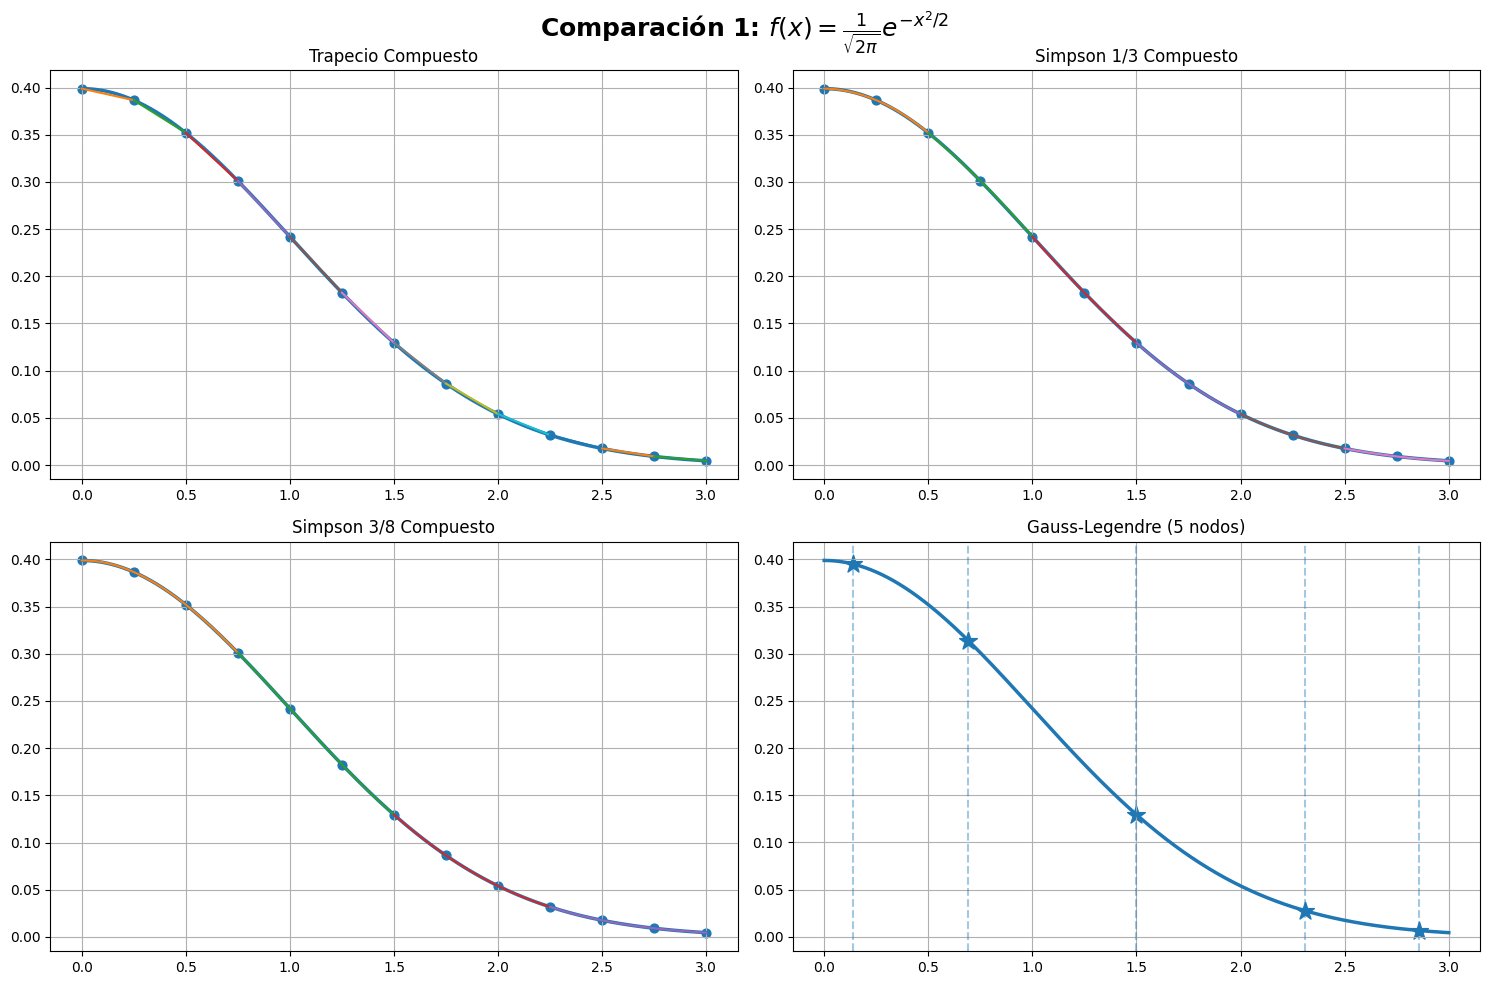

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import lagrange
from numpy.polynomial.legendre import leggauss

def f(x):
    return (1/np.sqrt(2*np.pi))*np.exp(-x**2/2)

a = 0
b = 3
N = 12

x = np.linspace(a,b,3000)
y = f(x)

xn = np.linspace(a,b,N+1)
yn = f(xn)

fig, axs = plt.subplots(2,2,figsize=(15,10))

fig.suptitle(
    r'Comparación 1: $f(x)=\frac{1}{\sqrt{2\pi}}e^{-x^2/2}$',
    fontsize=18,
    fontweight='bold'
)

# Trapecio
ax=axs[0,0]
ax.plot(x,y,lw=2.5)
for i in range(len(xn)-1):
    ax.plot([xn[i],xn[i+1]],[yn[i],yn[i+1]],lw=1.5)
ax.scatter(xn,yn,s=40)
ax.set_title("Trapecio Compuesto")
ax.grid(True)

# Simpson 1/3
ax=axs[0,1]
ax.plot(x,y,lw=2.5)
for i in range(0,N,2):
    xp=xn[i:i+3]
    yp=yn[i:i+3]
    p=lagrange(xp,yp)
    xx=np.linspace(xp[0],xp[-1],100)
    ax.plot(xx,p(xx),lw=1.5)
ax.scatter(xn,yn,s=40)
ax.set_title("Simpson 1/3 Compuesto")
ax.grid(True)

# Simpson 3/8
ax=axs[1,0]
ax.plot(x,y,lw=2.5)
for i in range(0,N,3):
    xp=xn[i:i+4]
    yp=yn[i:i+4]
    p=lagrange(xp,yp)
    xx=np.linspace(xp[0],xp[-1],100)
    ax.plot(xx,p(xx),lw=1.5)
ax.scatter(xn,yn,s=40)
ax.set_title("Simpson 3/8 Compuesto")
ax.grid(True)

# Gauss
ax=axs[1,1]
ax.plot(x,y,lw=2.5)

t,w=leggauss(5)
xg=(b-a)/2*t+(a+b)/2
yg=f(xg)

ax.scatter(xg,yg,s=180,marker='*')
for xi in xg:
    ax.axvline(xi,ls='--',alpha=0.4)

ax.set_title("Gauss-Legendre (5 nodos)")
ax.grid(True)

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()


Esta función corresponde a una distribución gaussiana. Presenta una variación suave y monotónica decreciente dentro del intervalo considerado. Tanto la pendiente como la curvatura cambian gradualmente, sin oscilaciones ni cambios bruscos de dirección.

Debido a este comportamiento regular, todos los métodos numéricos producen errores pequeños. Sin embargo, Gauss-Legendre alcanza una precisión comparable a Simpson utilizando únicamente 5 evaluaciones de la función, lo que demuestra una mayor eficiencia computacional.

### Función 2

$$
f(x)=\cos(x^2), \qquad x\in[0,2]
$$


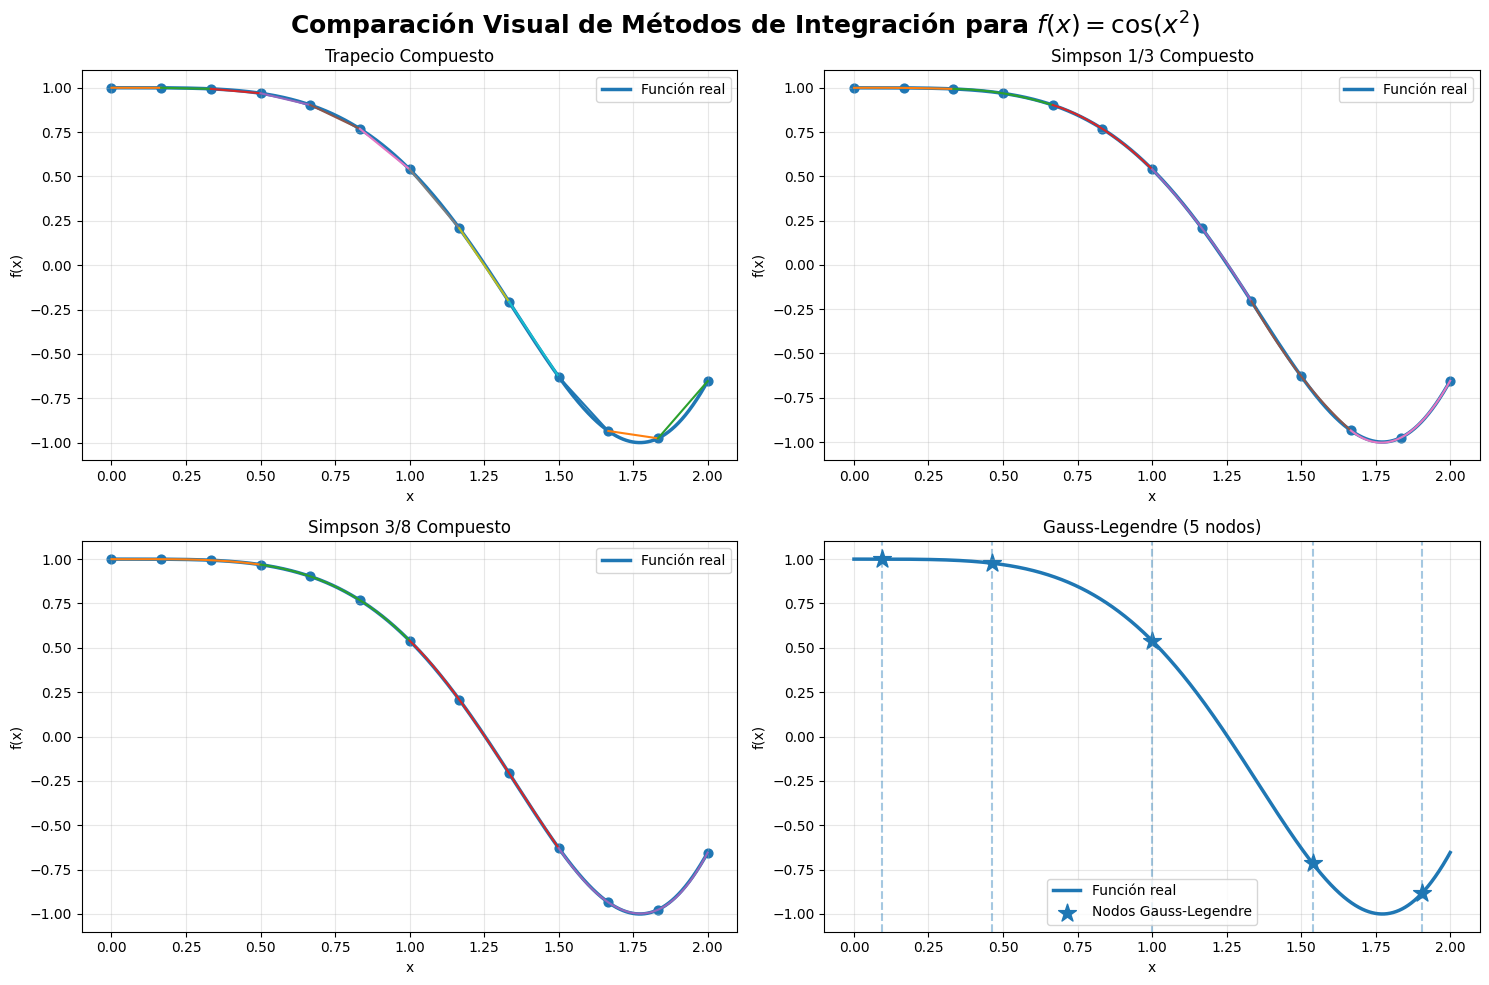

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import lagrange
from numpy.polynomial.legendre import leggauss

# ==========================================================
# FUNCIÓN
# ==========================================================

def f(x):
    return np.cos(x**2)

a = 0
b = 2
N = 12

x = np.linspace(a, b, 3000)
y = f(x)

xn = np.linspace(a, b, N+1)
yn = f(xn)

# ==========================================================
# FIGURA GENERAL
# ==========================================================

fig, axs = plt.subplots(2, 2, figsize=(15, 10))

fig.suptitle(
    r'Comparación Visual de Métodos de Integración para $f(x)=\cos(x^2)$',
    fontsize=18,
    fontweight='bold'
)

# ==========================================================
# 1) TRAPECIO COMPUESTO
# ==========================================================

ax = axs[0,0]

ax.plot(x, y, linewidth=2.5, label='Función real')

for i in range(len(xn)-1):
    ax.plot(
        [xn[i], xn[i+1]],
        [yn[i], yn[i+1]],
        linewidth=1.5
    )

ax.scatter(xn, yn, s=40)

ax.set_title('Trapecio Compuesto')
ax.grid(True, alpha=0.3)
ax.legend()

# ==========================================================
# 2) SIMPSON 1/3 COMPUESTO
# ==========================================================

ax = axs[0,1]

ax.plot(x, y, linewidth=2.5, label='Función real')

for i in range(0, N, 2):

    xp = xn[i:i+3]
    yp = yn[i:i+3]

    p = lagrange(xp, yp)

    xx = np.linspace(xp[0], xp[-1], 100)

    ax.plot(
        xx,
        p(xx),
        linewidth=1.5
    )

ax.scatter(xn, yn, s=40)

ax.set_title('Simpson 1/3 Compuesto')
ax.grid(True, alpha=0.3)
ax.legend()

# ==========================================================
# 3) SIMPSON 3/8 COMPUESTO
# ==========================================================

ax = axs[1,0]

ax.plot(x, y, linewidth=2.5, label='Función real')

for i in range(0, N, 3):

    xp = xn[i:i+4]
    yp = yn[i:i+4]

    p = lagrange(xp, yp)

    xx = np.linspace(xp[0], xp[-1], 100)

    ax.plot(
        xx,
        p(xx),
        linewidth=1.5
    )

ax.scatter(xn, yn, s=40)

ax.set_title('Simpson 3/8 Compuesto')
ax.grid(True, alpha=0.3)
ax.legend()

# ==========================================================
# 4) GAUSS-LEGENDRE
# ==========================================================

ax = axs[1,1]

ax.plot(x, y, linewidth=2.5, label='Función real')

n_gauss = 5

t, w = leggauss(n_gauss)

xg = (b-a)/2 * t + (a+b)/2
yg = f(xg)

ax.scatter(
    xg,
    yg,
    s=180,
    marker='*',
    label='Nodos Gauss-Legendre'
)

for xi in xg:
    ax.axvline(
        xi,
        linestyle='--',
        alpha=0.4
    )

ax.set_title('Gauss-Legendre (5 nodos)')
ax.grid(True, alpha=0.3)
ax.legend()

# ==========================================================
# FORMATO FINAL
# ==========================================================

for ax in axs.flat:
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')

plt.tight_layout()
plt.subplots_adjust(top=0.92)

plt.savefig(
    'comparacion_metodos_integracion.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


Esta función presenta un comportamiento oscilatorio creciente. A medida que aumenta el valor de $x$, la frecuencia de oscilación también aumenta debido al término cuadrático del argumento.

La derivada

$$
f'(x)=-2x\sin(x^2)
$$

muestra que la pendiente puede variar rápidamente en magnitud cuando $x$ crece.

Asimismo, la segunda derivada

$$
f''(x)=-2\sin(x^2)-4x^2\cos(x^2)
$$

indica que la curvatura aumenta considerablemente hacia el extremo derecho del intervalo.

Como consecuencia, los métodos de Newton-Cotes presentan mayores dificultades para aproximar el área bajo la curva utilizando puntos equiespaciados. Esto se refleja en los resultados obtenidos, donde el error del Trapecio Compuesto fue del orden de $10^{-3}$, significativamente superior al observado en la primera integral.

### Función 3

$$
f(x)=x^5-2x^3+4, \qquad x\in[-2,3]
$$


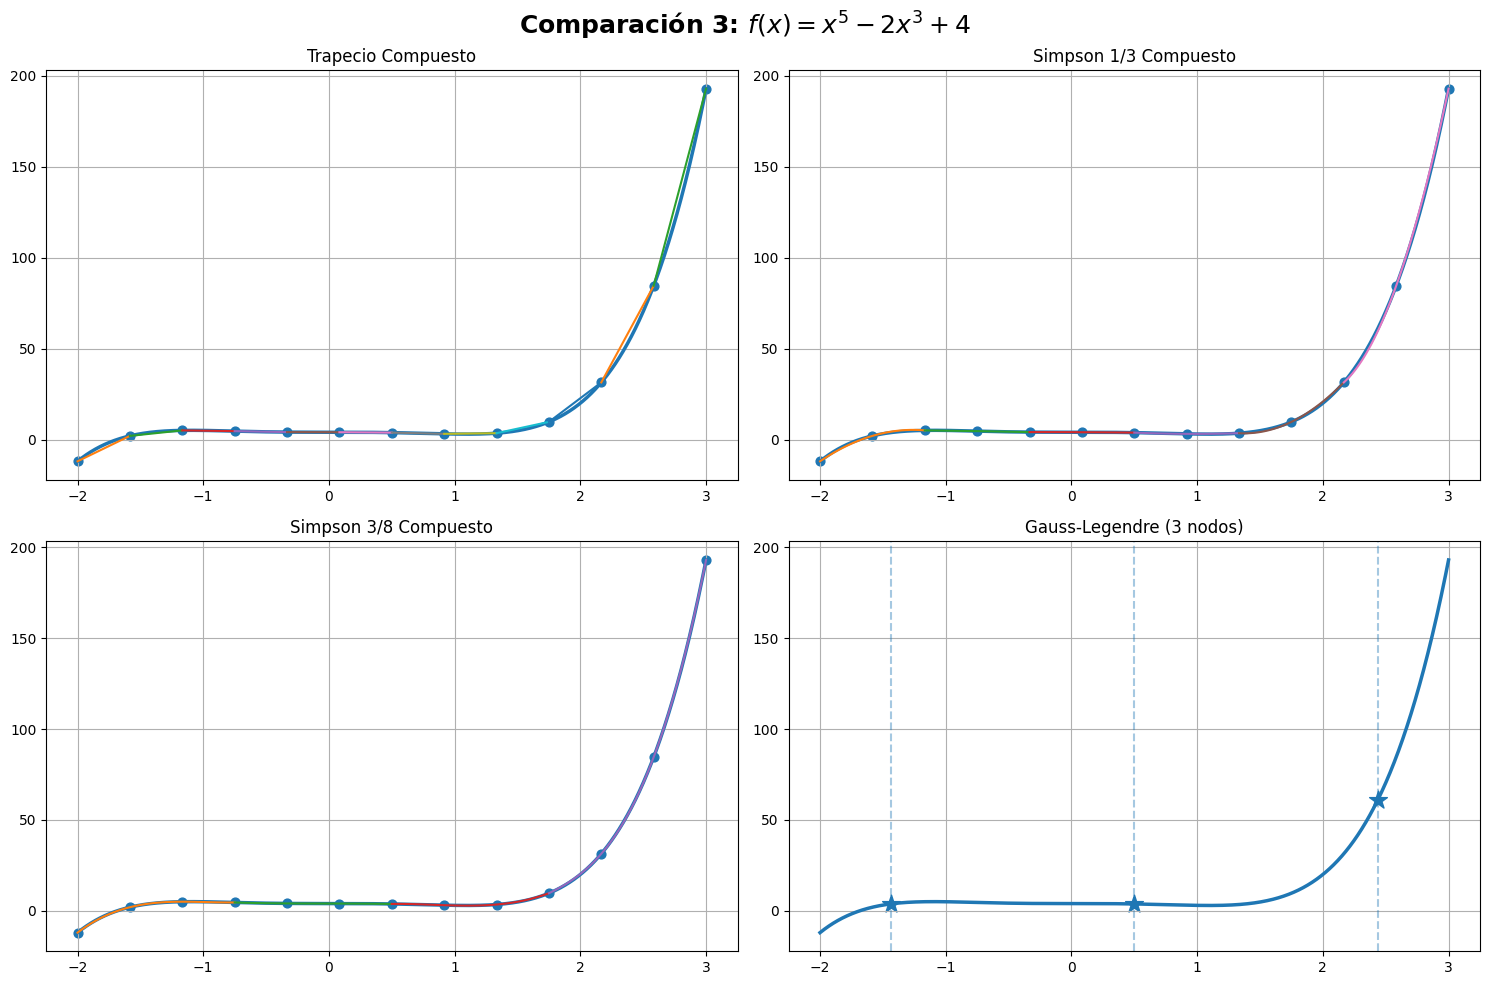

In [37]:
 import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import lagrange
from numpy.polynomial.legendre import leggauss

def f(x):
    return x**5 - 2*x**3 + 4

a = -2
b = 3
N = 12

x = np.linspace(a,b,3000)
y = f(x)

xn = np.linspace(a,b,N+1)
yn = f(xn)

fig, axs = plt.subplots(2,2,figsize=(15,10))

fig.suptitle(
    r'Comparación 3: $f(x)=x^5-2x^3+4$',
    fontsize=18,
    fontweight='bold'
)

# Trapecio
ax=axs[0,0]
ax.plot(x,y,lw=2.5)
for i in range(len(xn)-1):
    ax.plot([xn[i],xn[i+1]],[yn[i],yn[i+1]],lw=1.5)
ax.scatter(xn,yn,s=40)
ax.set_title("Trapecio Compuesto")
ax.grid(True)

# Simpson 1/3
ax=axs[0,1]
ax.plot(x,y,lw=2.5)
for i in range(0,N,2):
    xp=xn[i:i+3]
    yp=yn[i:i+3]
    p=lagrange(xp,yp)
    xx=np.linspace(xp[0],xp[-1],100)
    ax.plot(xx,p(xx),lw=1.5)
ax.scatter(xn,yn,s=40)
ax.set_title("Simpson 1/3 Compuesto")
ax.grid(True)

# Simpson 3/8
ax=axs[1,0]
ax.plot(x,y,lw=2.5)
for i in range(0,N,3):
    xp=xn[i:i+4]
    yp=yn[i:i+4]
    p=lagrange(xp,yp)
    xx=np.linspace(xp[0],xp[-1],100)
    ax.plot(xx,p(xx),lw=1.5)
ax.scatter(xn,yn,s=40)
ax.set_title("Simpson 3/8 Compuesto")
ax.grid(True)

# Gauss
ax=axs[1,1]
ax.plot(x,y,lw=2.5)

t,w=leggauss(3)
xg=(b-a)/2*t+(a+b)/2
yg=f(xg)

ax.scatter(xg,yg,s=180,marker='*')

for xi in xg:
    ax.axvline(xi,ls='--',alpha=0.4)

ax.set_title("Gauss-Legendre (3 nodos)")
ax.grid(True)

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()


Esta función no es oscilatoria, pero sí presenta regiones de elevada pendiente y curvatura debido a su carácter polinómico de quinto grado.

Las derivadas

$$
f'(x)=5x^4-6x^2
$$

y

$$
f''(x)=20x^3-12x
$$

evidencian que la pendiente y la curvatura aumentan rápidamente conforme $|x|$ crece.

En consecuencia, las aproximaciones lineales o cuadráticas empleadas por los métodos compuestos de Newton-Cotes no representan exactamente el comportamiento de la función en todo el intervalo, generando errores apreciables incluso utilizando 13 puntos de evaluación.

Por el contrario, la cuadratura de Gauss-Legendre con $n=3$ obtuvo prácticamente el valor exacto de la integral. Esto se debe a que una cuadratura de Gauss con $n$ nodos integra exactamente polinomios de grado hasta $2n-1$. Como la función es de grado 5, tres nodos son suficientes para lograr exactitud teórica.



### Comparación General

Los resultados obtenidos muestran que el error de los métodos de Newton-Cotes aumenta cuando la función presenta alta curvatura, cambios rápidos de pendiente u oscilaciones. Esto ocurre porque dichos métodos utilizan puntos igualmente espaciados y aproximan la función mediante interpolaciones locales.

En contraste, la cuadratura de Gauss-Legendre emplea nodos óptimos calculados a partir de los polinomios de Legendre. Esta distribución permite capturar de manera más eficiente la información relevante de la función dentro del intervalo de integración.

Por esta razón, Gauss-Legendre mantiene errores muy pequeños incluso en funciones con elevada curvatura u oscilación, utilizando menos evaluaciones de la función que los métodos compuestos tradicionales.


<div style="
width:23cm;
max-width:23cm;
box-sizing:border-box;
margin:auto;
background-color:#F2F0E6;
border-top:2px solid #444;
padding:20px;
font-family:Georgia;
overflow:hidden;
line-height:1.7;
text-align:justify;
text-justify:inter-word;
">

### **Pregunta 3: Límites del Método**

Si la función fuera:

**P(x) = 7x⁷ − 3x⁴ + 2x**

¿Cuántos nodos \(n\) requeriría Gauss-Legendre para obtener un error absoluto exactamente igual a cero?

**Sugerencia:** Justifique utilizando el teorema del grado de precisión máxima.

</div>

<div style="
width:231m;
max-width:21cm;
box-sizing:border-box;
margin:auto;
background-color:#F2F0E6;
border-top:2px solid #444;
padding:20px;
font-family:Georgia;
overflow:hidden;
line-height:1.7;
text-align:justify;
text-justify:inter-word;
">


## Solución 3. Límites